In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
# Ideal sims
ideal_infile="/grid/siepel/home/staklins/projects/crispr_barcode/data/uniform_50cells_50sites_0.0025mut_10-6mig_data_8_22_24/all_mig_informative_mutation_counts.tsv"
ideal_df = pd.read_csv(ideal_infile, sep="\t", index_col=0)


In [66]:
fig, ax = plt.subplots(figsize=(8,6))
fs=20
sns.histplot(ideal_df['num_mig_informative_muts'], bins=30, kde=False, ax=ax, color='grey', edgecolor=None)
ax.set_xlabel("Number of metastasis-informative mutations", fontsize=fs)
ax.set_ylabel("Number of datasets", fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-4)
plt.tight_layout()
plt.savefig(ideal_infile.replace(".tsv", ".pdf"))
plt.close()

In [69]:
# Variable sims
variable_infile="/grid/siepel/home/staklins/projects/crispr_barcode/data/variable_migration_and_mutation_rates_8_19_24/all_mig_informative_mutation_counts.tsv"

variable_df = pd.read_csv(variable_infile, sep="\t", index_col=0)
variable_df['mutation_rate'] = [float("0." + str(x.split("_")[1].replace("mut",""))) for x in variable_df.index]
variable_df['migration_rate'] = [float(10**-int(x.split("_")[0].replace("mig",""))) for x in variable_df.index]



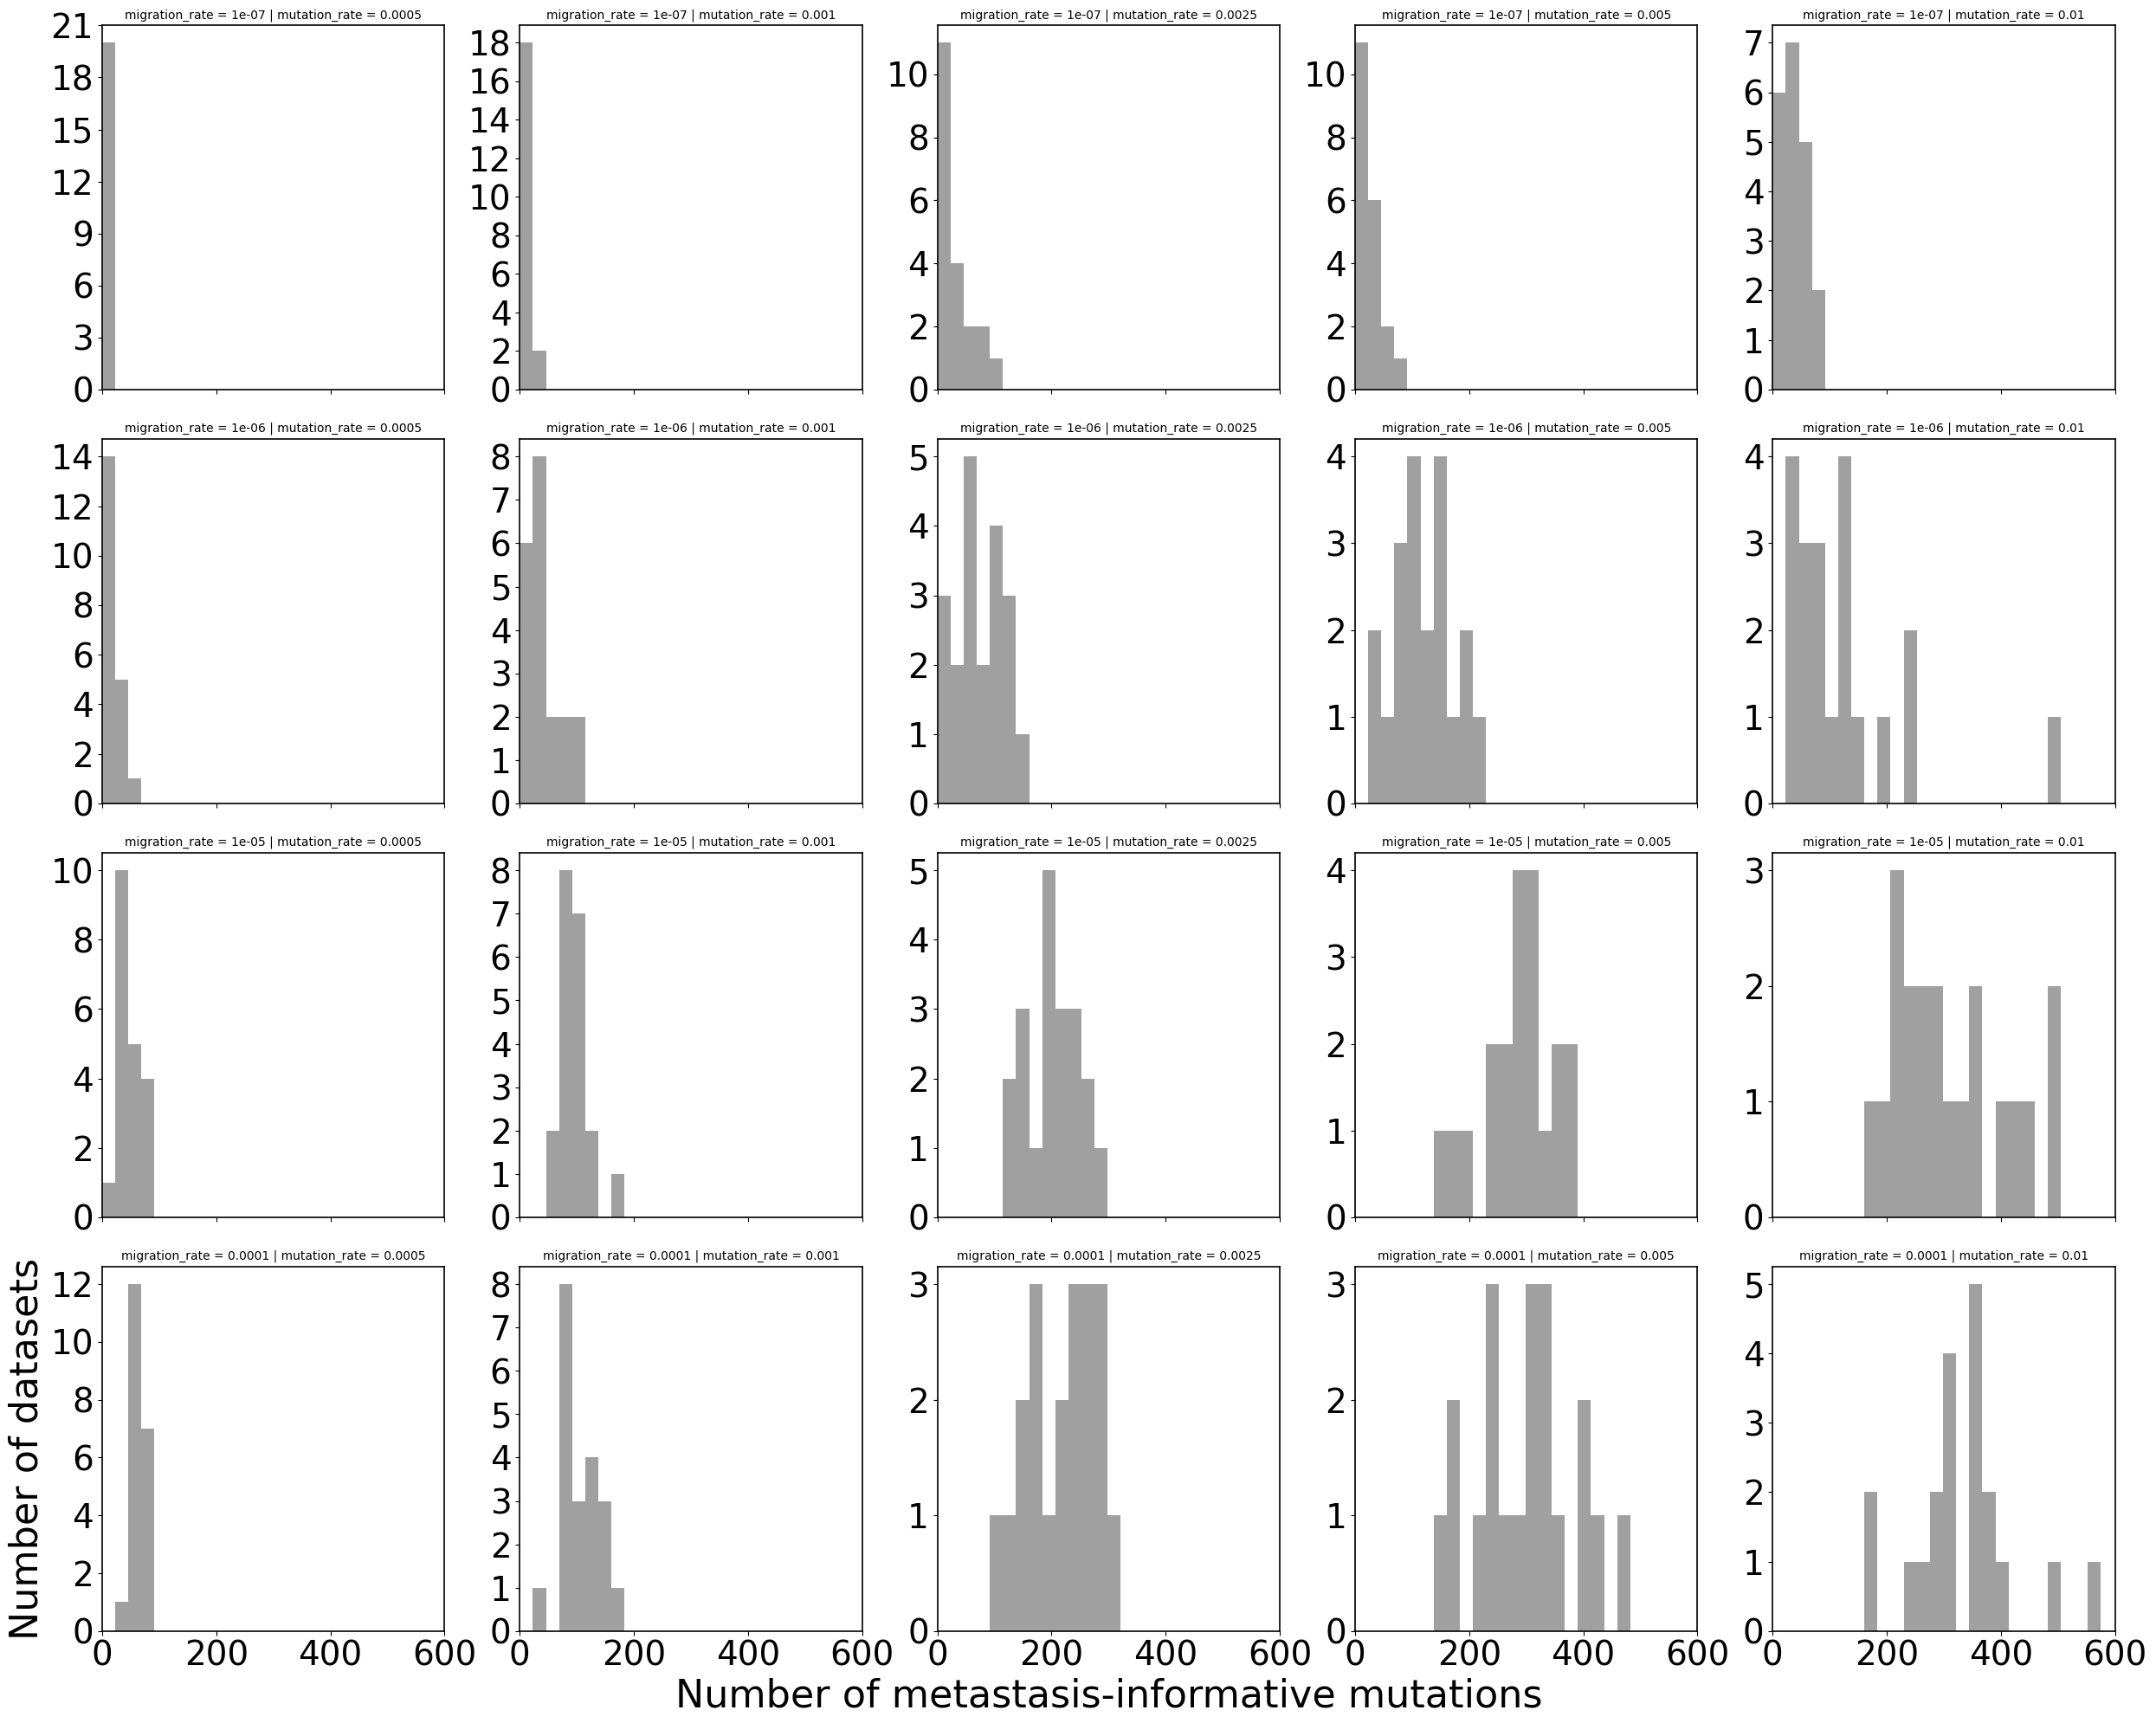

In [ ]:
import matplotlib.ticker as ticker

mut_order = sorted(variable_df['mutation_rate'].unique())
mig_order = sorted(variable_df['migration_rate'].unique(),)

fs = 32
g = sns.displot(
    data=variable_df,
    x="num_mig_informative_muts",
    col="mutation_rate",
    row="migration_rate",
    bins=25,
    color="grey",
    edgecolor=None,
    facet_kws={"sharex": True, "sharey": False},
    col_order=mut_order,
    row_order=mig_order,
)

n_rows, n_cols = g.axes.shape

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        # Draw all spines (full box)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        # Label only bottom-left subplot
        ax.set_xlabel("")
        ax.set_ylabel("")
        if i == n_rows - 1 and j == 0:
            ax.set_ylabel("Number of datasets", fontsize=fs)
        elif j == 2 and i == n_rows - 1:
            ax.set_xlabel("Number of metastasis-informative mutations", fontsize=fs)

        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        
        ax.set_xlim(0, 600) # values determined from data
        ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
        
        # Ticks and font size for all
        ax.tick_params(axis="both", labelsize=fs - 4)


plt.tight_layout()
plt.show()
g.savefig(variable_infile.replace(".tsv", ".pdf"))
plt.close()


In [86]:
# NEED TO RE-LOAD THE NEW FILE, BUT FOR NOW WILL SET IT UP WITH THE OLD ONE
performance_variable_infile="/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/variable_migration_and_mutation_rates_data_8_19_24/initialBiorxivVersion_metient_oldDefaultWeights_archived_11_2_25/precision_recall_curve/metrics.csv"

performance_variable_df = pd.read_csv(performance_variable_infile, sep=",", index_col=0)
cols_to_keep = [col for col in performance_variable_df.columns if "f1" in col]
performance_variable_df = performance_variable_df[cols_to_keep]

variable_df['avg_informative_muts_per_mig_edge'] = variable_df['num_mig_informative_muts'] / variable_df['num_migration_edges']
variable_df = variable_df['avg_informative_muts_per_mig_edge'].to_frame()

merged_df = variable_df.merge(performance_variable_df, left_index=True, right_index=True)
merged_df

,avg_informative_muts_per_mig_edge,Random_f1,Consensus_f1,Parsimony_f1,MACHINA_f1,MACH2_f1,Metient_f1,BEAM_f1
mig4_mut0025_2528,7.882353,0.237624,0.432432,0.774194,0.838710,0.838710,0.750000,0.866667
mig6_mut0025_1983,7.875000,0.273684,0.451613,0.642857,0.785714,0.785714,0.785714,0.740741
mig5_mut0025_4262,8.096774,0.253968,0.297297,0.344828,0.271186,0.482759,0.312500,0.454545
mig6_mut0005_31114,2.111111,0.131868,0.545455,1.000000,0.888889,0.888889,0.888889,0.875000
mig6_mut01_32163,7.375000,0.142857,0.166667,0.714286,0.785714,0.785714,0.785714,0.692308
...,...,...,...,...,...,...,...,...
mig7_mut01_10788,2.000000,0.034483,0.250000,1.000000,1.000000,1.000000,1.000000,1.000000
mig5_mut005_6169,14.842105,0.134615,0.347826,0.594595,0.540541,0.594595,0.578947,0.857143
mig6_mut0005_10026,1.500000,0.055556,0.363636,0.571429,0.571429,0.571429,0.500000,1.000000
mig5_mut0025_983,5.826087,0.171429,0.560000,0.439024,0.682927,0.666667,0.409091,0.750000


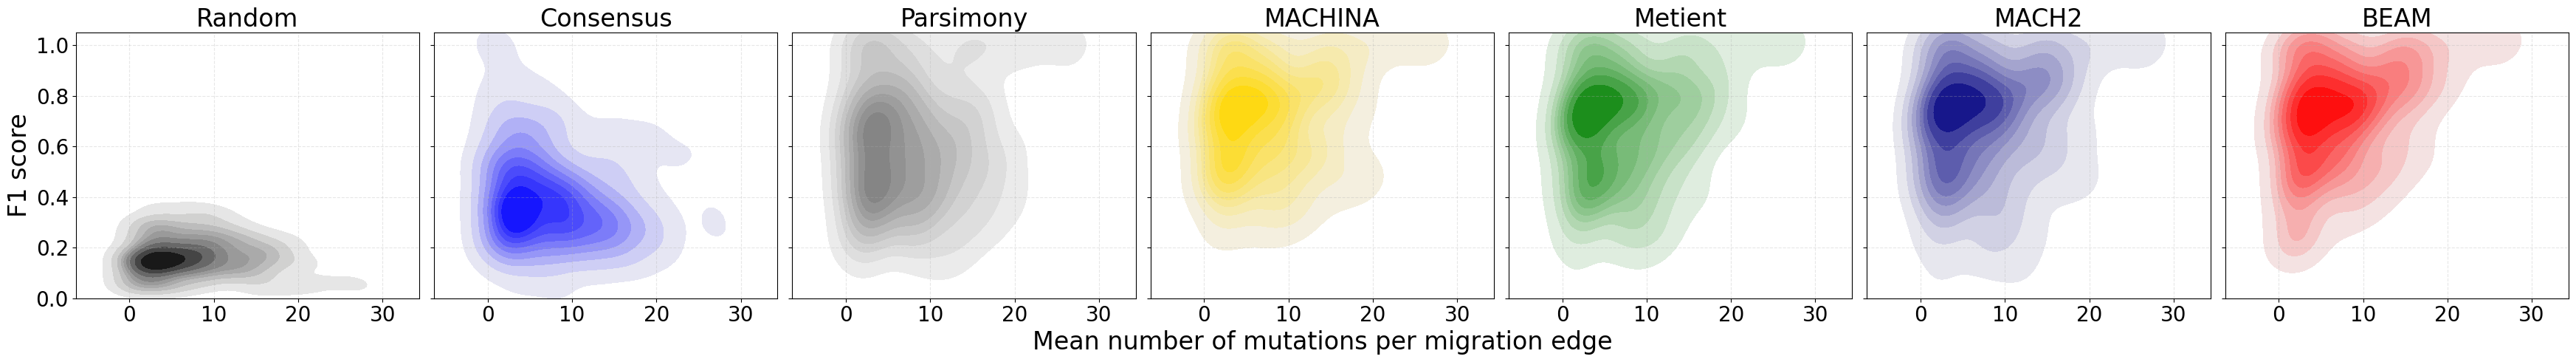

In [127]:
# methods = [col.replace("_f1","") for col in merged_df.columns if "f1" in col]
methods = ["Random", "Consensus", "Parsimony", "MACHINA", "Metient", "MACH2", "BEAM"]   # Manually set order

method_colors = {
    "BEAM": "red",
    "MACH2": "navy",
    "Metient": "green",
    "PathFinder": "orange",
    "MACHINA": "gold",
    "Fitch-Hartigan": "purple",
    "Consensus": "blue",
    "Random": "black",
}

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 5), sharey=True)
fs = 24

for i, method in enumerate(methods):
    ax = axes[i]
    
    # sns.scatterplot(
    #     data=merged_df,
    #     x="avg_informative_muts_per_mig_edge",
    #     y=f"{method}_f1",
    #     ax=ax,
    #     s=50,
    #     alpha=0.5,
    #     edgecolor=None,
    #     linewidth=1.0,
    #     color=method_colors.get(method, "grey"),
    # )
    
    sns.kdeplot(
        data=merged_df,
        x="avg_informative_muts_per_mig_edge",
        y=f"{method}_f1",
        fill=True,
        thresh=0.05,
        levels=10,
        cmap=sns.light_palette(method_colors.get(method, "grey"), as_cmap=True),
        ax=ax,
    )
    
    
    ax.set_title(method, fontsize=fs)
    if i == 3:
        ax.set_xlabel("Mean number of mutations per migration edge", fontsize=fs)
    else:
        ax.set_xlabel("")
        
    if i == 0:
        ax.set_ylabel("F1 score", fontsize=fs)
    else:
        ax.set_ylabel("")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=fs - 4)


plt.tight_layout()
plt.show()